In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from datetime import datetime
import mne
from mne.channels import make_standard_montage
from mne.preprocessing import ICA

data_path = "data/Malak Tamimi1748950961776_EPOCX_211983_2025.06.03T14.42.43+03.00.md.pm.bp.mc.fe.csv"
df = pd.read_csv(data_path)
log = "data_logs/Malak Tamimi/Malak Tamimi_run1748950961776.txt"

In [2]:
def add_three_hours(timestamp):
    k = timestamp.split('T')
    k[1]= str(int(k[1][:2])+3)+k[1][2:]
    return 'T'.join(k)
def mp(c):
    """Convert log color markers to valid Plotly colors"""
    if c.strip()=="'blue'":
        return 'blue'
    if c.strip()=="'lightblue'":
        return 'red'
    return 'black'

logs = {}
for log_file in [log]:
    if not log_file.endswith('.txt'):
        continue
    identifier = log_file.split("_run")[1].split(".")[0]
    try:
        with open(f"{log_file}", "r") as f:
            a = f.readlines()
            if not a:
                print(f"WARNING: Empty log file: {log_file}")
                continue
            logs[identifier] = [
                (datetime.strptime(add_three_hours(line.split(" ")[0]), "[%Y-%m-%dT%H:%M:%S.%fZ]").timestamp(),
                mp(line.split(" ")[-1]),
                " ".join(line.split(" ")[2:]))
                for line in a
                if 'blue' in line or '+' in line
            ]
    except Exception as e:
        print(f"ERROR parsing log file {log_file}: {str(e)}")

In [3]:
def alt_pipeline(file_path):
    df = pd.read_csv(file_path)
    df.drop(columns=["EEG.Interpolated", "OriginalTimestamp", "EEG.MarkerHardware", "EEG.BatteryPercent", "MOT.CounterMems", "MOT.InterpolatedMems", 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY',
        'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ', "EEG.Battery", "EQ.SampleRateQuality", "PM.Engagement.IsActive", "PM.Excitement.IsActive", "PM.Stress.IsActive", "PM.Relaxation.IsActive", "PM.Interest.IsActive",'MC.Action', 'MC.ActionPower', 'MC.IsActive', 'CQ.AF3', 'CQ.F7', 'CQ.F3', 'CQ.FC5', 'CQ.T7', 'CQ.P7', 'CQ.O1',
        'CQ.O2', 'CQ.P8', 'CQ.T8', 'CQ.FC6', 'CQ.F4', 'CQ.F8', 'CQ.AF4',
        'CQ.Overall', 'EQ.OVERALL', 'EQ.AF3', 'EQ.F7', 'EQ.F3', 'EQ.FC5', 'EQ.T7', 'EQ.P7',
        'EQ.O1', 'EQ.O2', 'EQ.P8', 'EQ.T8', 'EQ.FC6', 'EQ.F4', 'EQ.F8', 'MarkerType', 'MarkerIndex', 'MarkerValueInt',
        'EQ.AF4'], inplace=True, errors='ignore')
    
    try:
        timestamps = pd.to_numeric(df['Timestamp'], errors='coerce')
        timestamps = timestamps[~np.isnan(timestamps)]
        if len(timestamps) > 1:
                sfreq = 1.0 / np.median(np.diff(timestamps))
                if not (10 < sfreq < 1000):
                    print(f"Warning: Calculated sfreq ({sfreq:.2f} Hz) seems unusual. Falling back to 128 Hz.")
                    sfreq = 128.0
        else:
                print("Warning: Not enough valid 'Timestamp' values to calculate sfreq. Falling back to 128 Hz.")
                sfreq = 128.0
    except Exception as e:
        print(f"Warning: Error processing 'Timestamp' column: {e}. Falling back to 128 Hz.")
        sfreq = 128.0
    df.index = df['Timestamp']
    df.drop("Timestamp", axis=1,inplace=True)
    return df, sfreq

In [4]:
processed, sfreq = alt_pipeline(data_path)

In [5]:
processed

,EEG.Counter,EEG.AF3,EEG.F7,EEG.F3,EEG.FC5,EEG.T7,EEG.P7,EEG.O1,EEG.O2,EEG.P8,...,POW.AF4.Alpha,POW.AF4.BetaL,POW.AF4.BetaH,POW.AF4.Gamma,FE.BlinkWink,FE.HorizontalEyesDirection,FE.UpperFaceAction,FE.UpperFaceActionPower,FE.LowerFaceAction,FE.LowerFaceActionPower
Timestamp,,,,,,,,,,,,,,,,,,,,,
1.748951e+09,17.0,4264.743652,4335.384766,4267.179688,4288.461426,4307.179688,4334.230957,4339.487305,4392.820313,4383.846191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.748951e+09,18.0,4259.743652,4330.384766,4268.974121,4288.205078,4301.025879,4335.384766,4340.769043,4394.102539,4382.948730,...,4.414459,1.035282,0.464645,0.313603,0.0,0.0,64.0,0.056977,1.0,0.0
1.748951e+09,19.0,4257.563965,4327.563965,4272.948730,4290.128418,4300.000000,4340.512695,4346.538574,4397.692383,4385.256348,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.748951e+09,20.0,4257.948730,4326.666504,4277.948730,4292.436035,4303.846191,4346.538574,4352.820313,4400.512695,4389.102539,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.748951e+09,21.0,4258.717773,4326.538574,4281.922852,4293.461426,4310.641113,4351.666504,4357.179688,4402.948730,4393.205078,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.748952e+09,188.0,4400.000000,4394.487305,4282.692383,4297.179688,4315.000000,4345.256348,4356.410156,4433.846191,4398.461426,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.748952e+09,189.0,4404.230957,4403.461426,4286.794922,4300.384766,4316.666504,4350.897461,4363.846191,4433.846191,4398.461426,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.748952e+09,190.0,4401.922852,4408.589844,4288.077148,4301.153809,4316.922852,4357.692383,4372.820313,4438.846191,4405.256348,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
def eeg_only(df):
    eeg_cols = [col for col in df.columns if (col.startswith('EEG.')) and col not in ['EEG.Counter', 'EEG.RawCq']]
    return df[eeg_cols]

Using matplotlib as 2D backend.


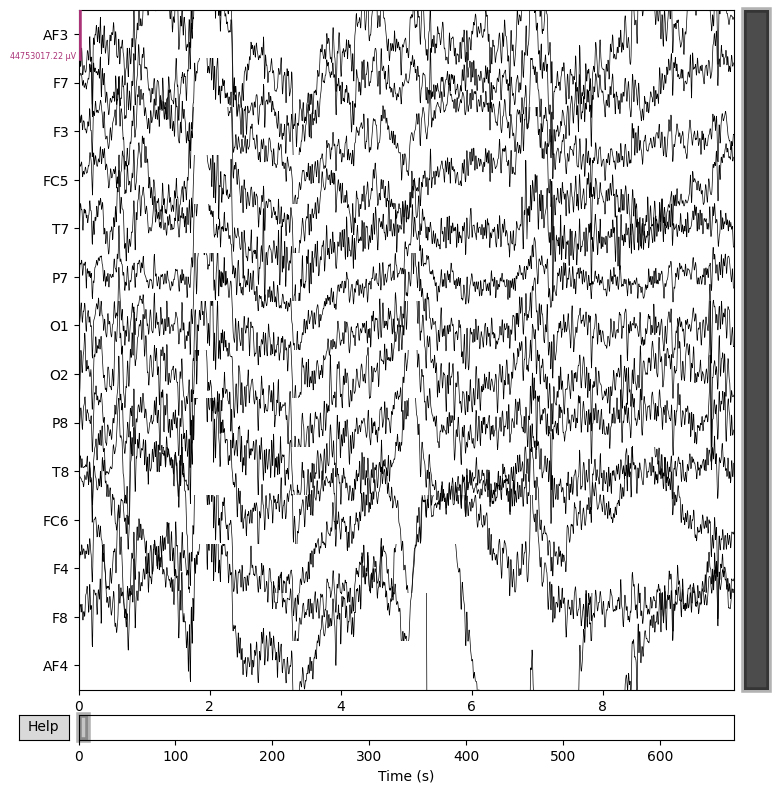

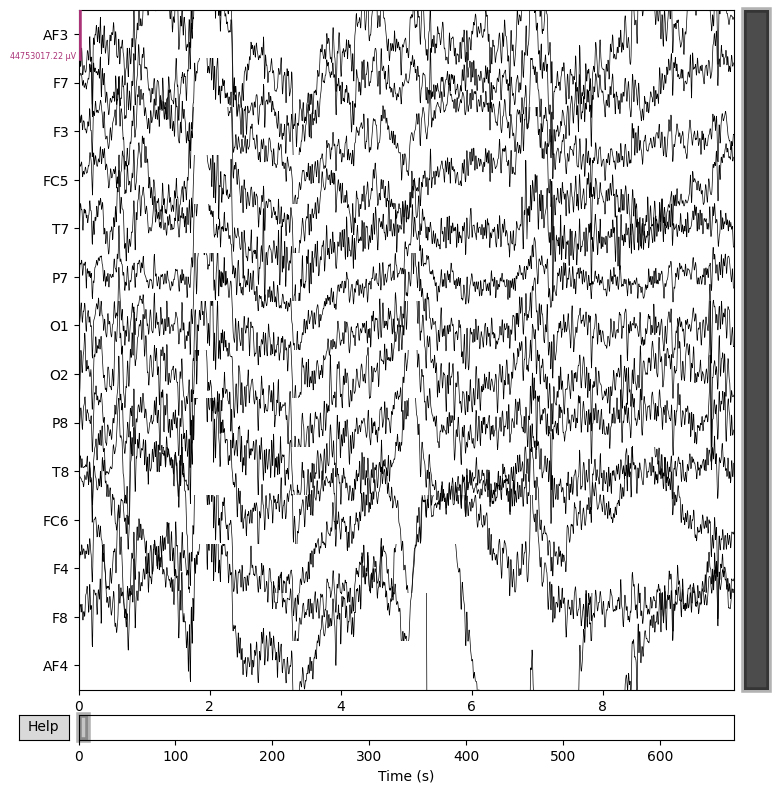

In [7]:
processed = eeg_only(processed)
data = processed.values.T
ch_names = [name.split('.')[1] for name in processed.columns.tolist()]
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=(['eeg']*len([i for i in processed.columns if i.startswith('EEG.')]))+['bio']*len([i for i in processed.columns if i.startswith('FE.')]))
raw = mne.io.RawArray(data, info, verbose=False)
montage = make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='warn')

raw.plot(scalings='auto', show=True, block=True)

In [8]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: AF3, F7, F3, FC5, T7, P7, O1, O2, P8, T8, FC6, F4, F8, AF4
 chs: 14 EEG
 custom_ref_applied: False
 dig: 17 items (3 Cardinal, 14 EEG)
 highpass: 0.0 Hz
 lowpass: 128.1 Hz
 meas_date: unspecified
 nchan: 14
 projs: []
 sfreq: 256.1 Hz
>

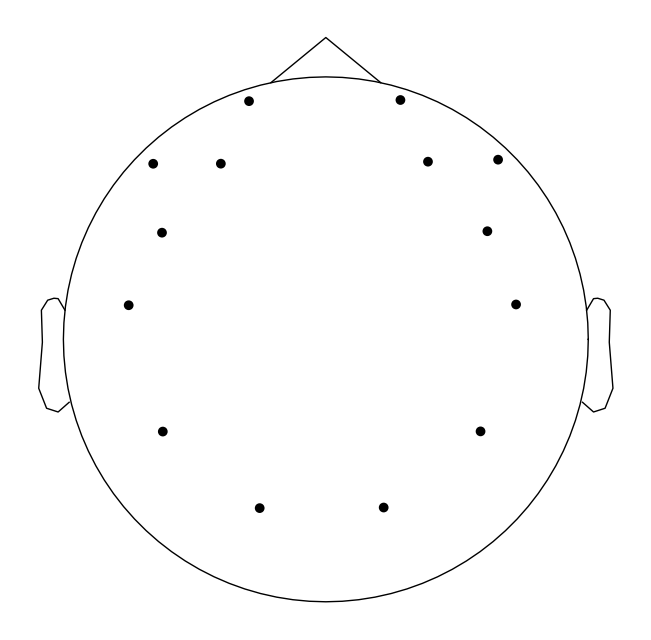

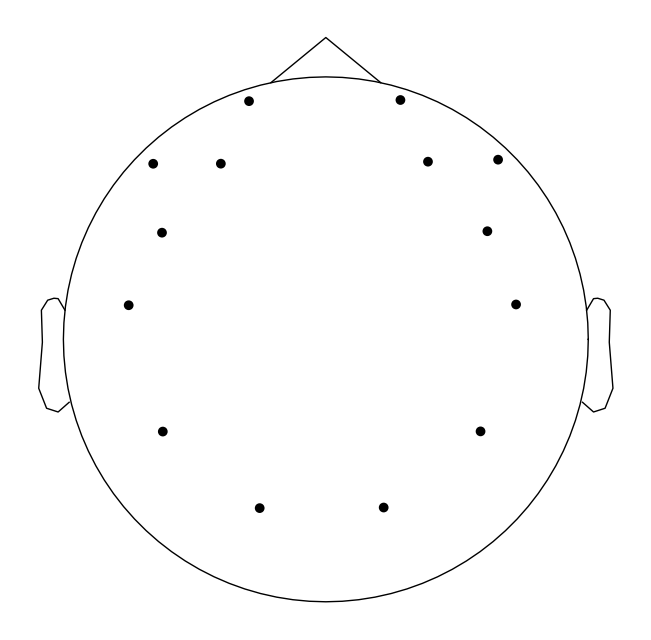

In [9]:
raw.plot_sensors()

In [10]:

event_id = {
    'covert_speech': 1,
    'overt_speech': 2,
    'fixation': 3,
}
    
events = []
raw_index = processed.index

for timestamp, color, description in logs["1748950961776"]:
    sample_idx = np.searchsorted(raw_index, timestamp)

    if sample_idx >= len(raw_index) or sample_idx < 0:
        continue
        
    if color == 'blue':
        event_type = event_id['covert_speech']
    elif color == 'red':
        event_type = event_id['overt_speech']
    elif color == 'black':
        event_type = event_id['fixation']
    else:
        continue  
        
    events.append([sample_idx, 0, event_type])

events = np.array(events, dtype=int)

print(f"Created {len(events)} events:")
for event_name, event_code in event_id.items():
    count = np.sum(events[:, 2] == event_code)
    print(f"  {event_name}: {count} events")


raw.filter(1, 64, fir_design="firwin")
raw_data = raw.get_data() * 1e-6 
raw._data = raw_data
reject = dict(eeg=200e-6) 
epochs = mne.Epochs(raw, events, reject=reject, event_id=event_id, picks='eeg', event_repeated='drop')

Created 800 events:
  covert_speech: 130 events
  overt_speech: 130 events
  fixation: 540 events
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 64.00 Hz
- Upper transition bandwidth: 16.00 Hz (-6 dB cutoff frequency: 72.00 Hz)
- Filter length: 847 samples (3.307 s)

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
589 matching events found
Setting baseline interval to [-0.19910931587219238, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


In [11]:
ica = mne.preprocessing.ICA(n_components=14, method='picard', random_state=15)
ica.fit(raw)

Fitting ICA to data using 14 channels (please be patient, this may take a while)
Selecting by number: 14 components
Fitting ICA took 15.8s.


Method,picard
Fit parameters,max_iter=500
Fit,42 iterations on raw data (173232 samples)
ICA components,14
Available PCA components,14
Channel types,eeg
ICA components marked for exclusion,—


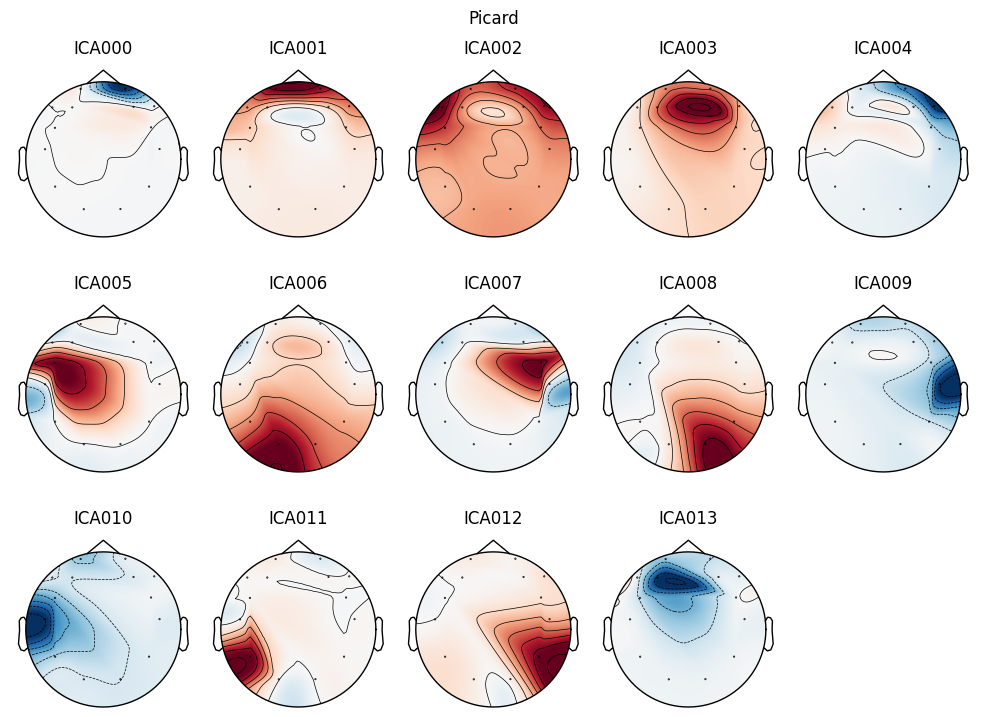

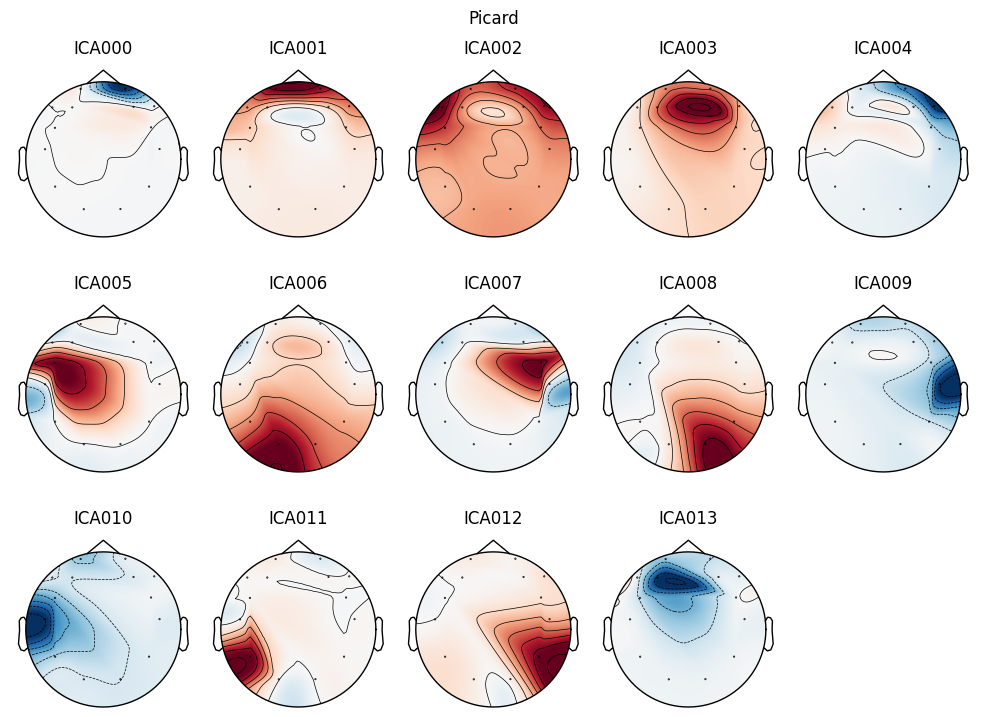

In [12]:
ica.plot_components(title="Picard")

Creating RawArray with float64 data, n_channels=14, n_times=173232
    Range : 0 ... 173231 =      0.000 ...   676.312 secs
Ready.


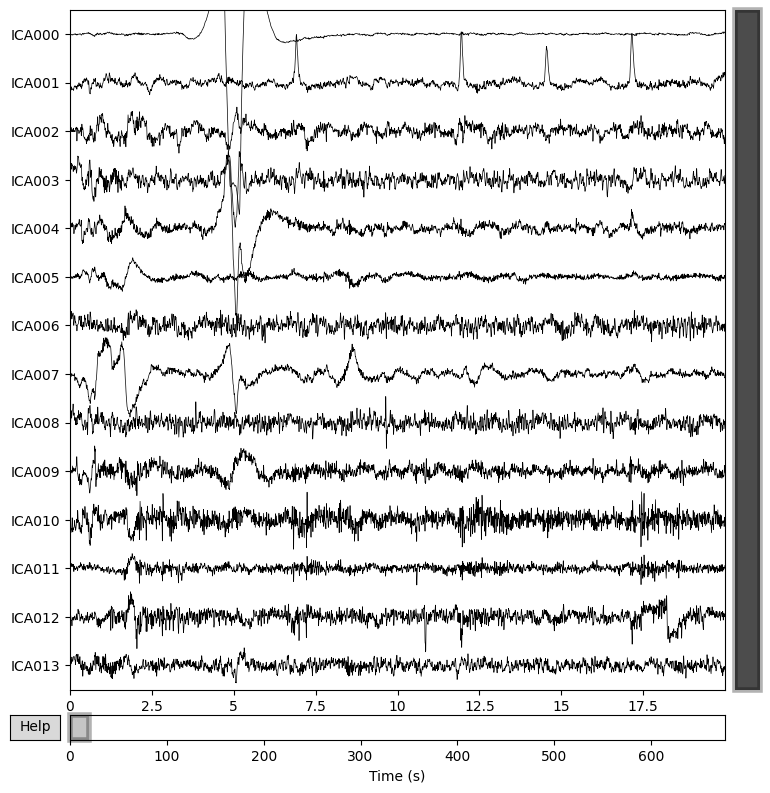

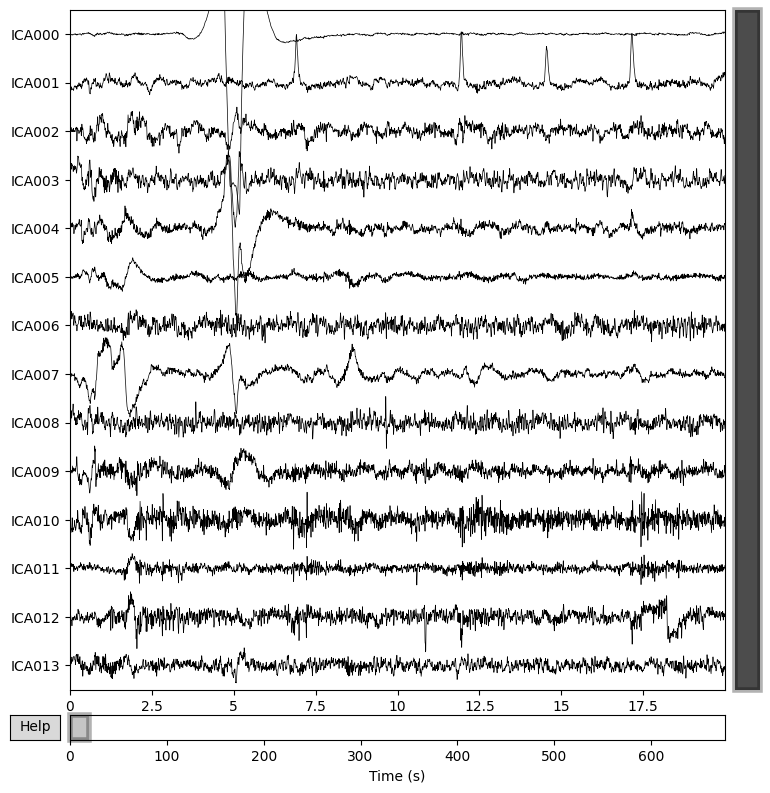

In [17]:
ica.plot_sources(raw)

In [14]:
epochs

<Epochs | 589 events (good & bad), -0.199 – 0.5 s (baseline -0.199 – 0 s), ~22 KiB, data not loaded,
 'covert_speech': 130
 'overt_speech': 130
 'fixation': 329>

Using data from preloaded Raw for 589 events and 180 original time points ...
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['F8', 'AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['AF3', 'AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['P7', 'AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['FC6']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['AF3']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF3', 'AF4']
    Rejecting  epoch based on EEG : ['AF3', 'AF4']
    Rejecting  epoch based on EEG : ['AF3', 'AF4']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['AF4']
   

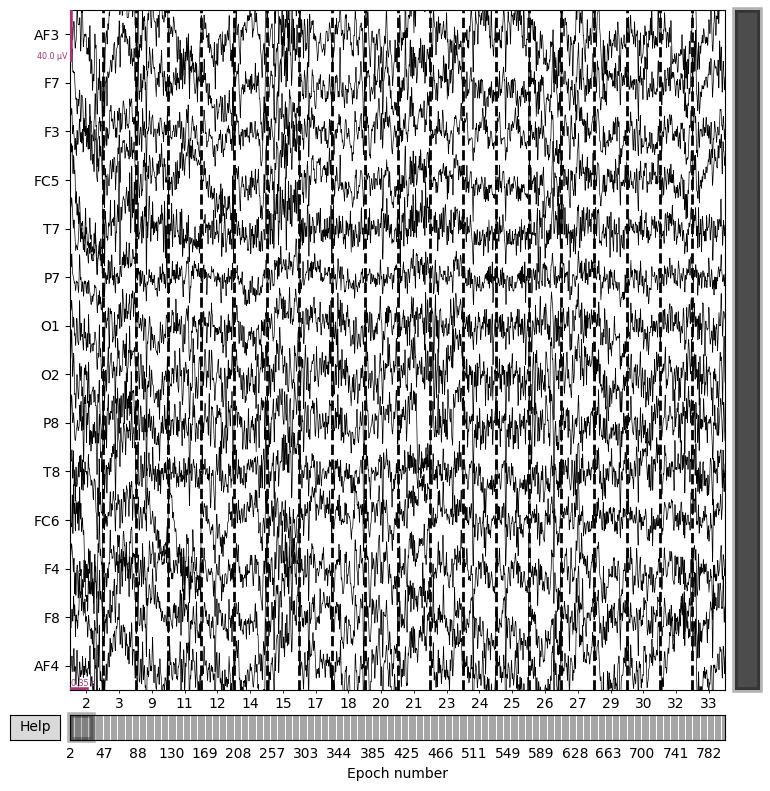

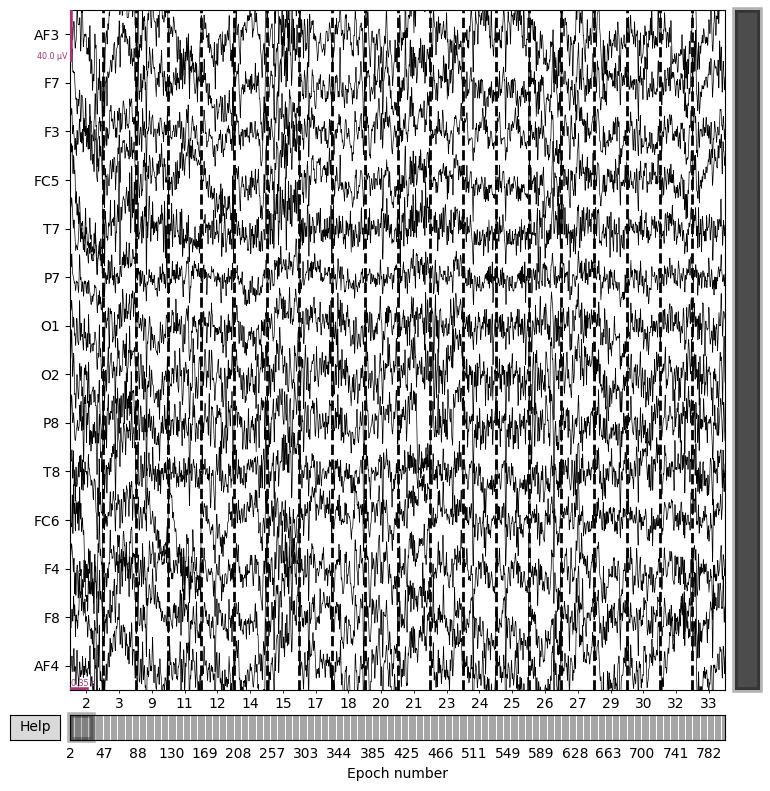

In [15]:
epochs.plot()

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


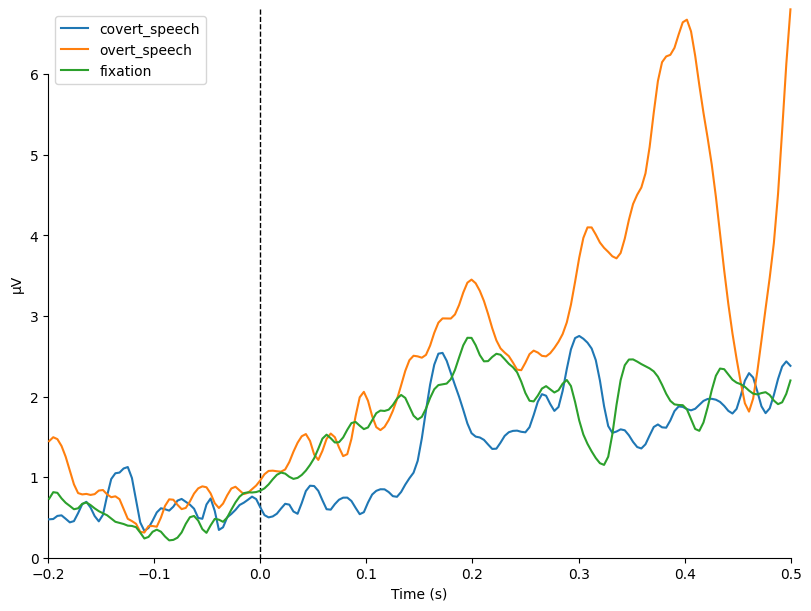

[<Figure size 800x600 with 1 Axes>]

In [16]:
mne.viz.plot_compare_evokeds([epochs['covert_speech'].average(), epochs['overt_speech'].average(), epochs['fixation'].average()])

In [18]:
ica.apply(raw, exclude=[0,1,4,7])

Applying ICA to Raw instance
    Transforming to ICA space (14 components)
    Zeroing out 4 ICA components
    Projecting back using 14 PCA components


<RawArray | 14 x 173232 (676.3 s), ~18.5 MiB, data loaded>

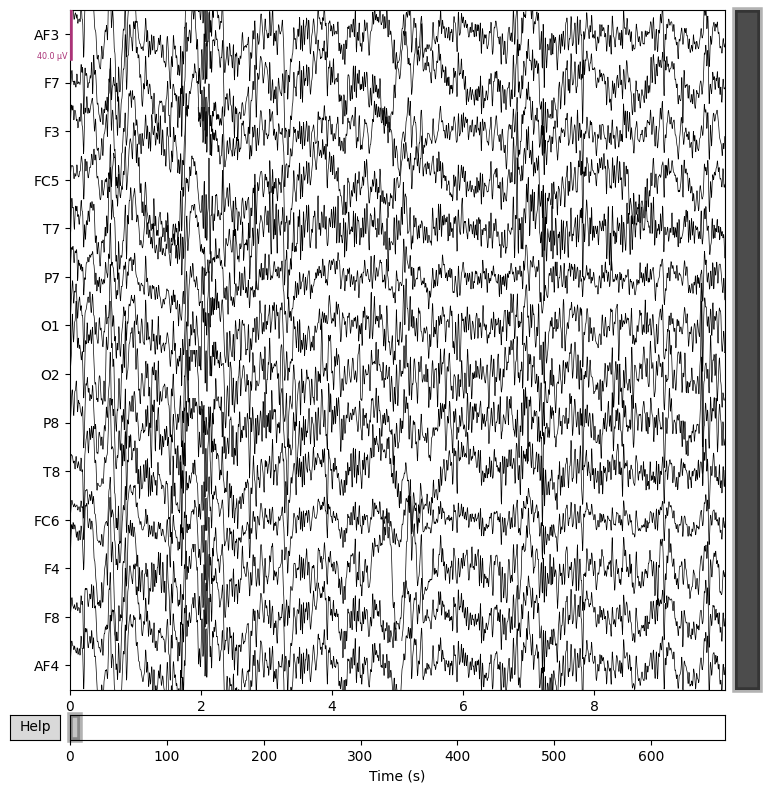

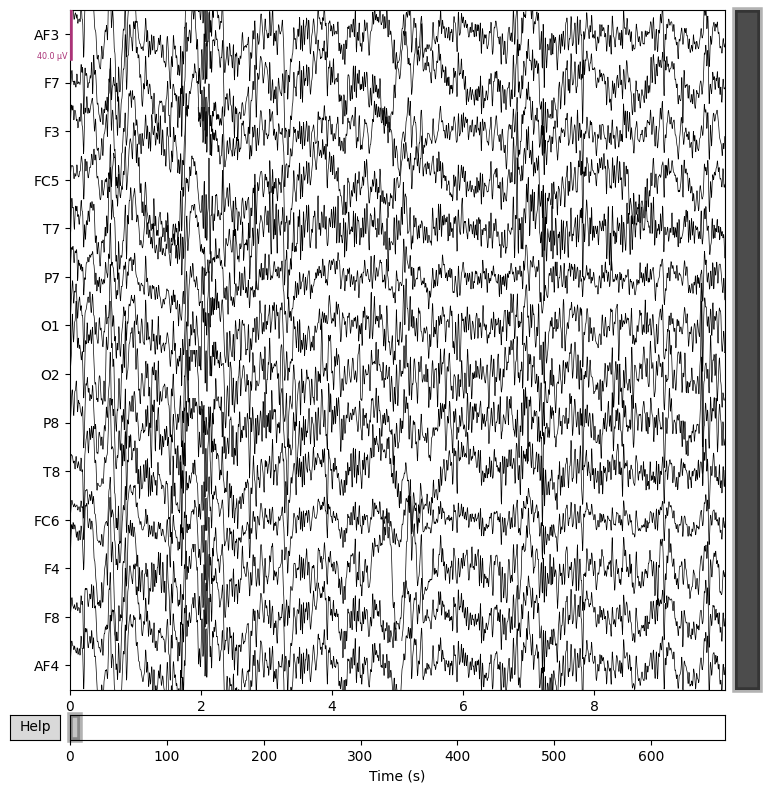

In [19]:
raw.plot()

Fitting ICA to data using 14 channels (please be patient, this may take a while)
Selecting by number: 14 components
Fitting ICA took 25.4s.
Creating RawArray with float64 data, n_channels=14, n_times=173232
    Range : 0 ... 173231 =      0.000 ...   676.312 secs
Ready.


/var/folders/h2/p1hlwwls3jz9yndby_s8f_y00000gn/T/ipykernel_16298/2419090834.py:2: RuntimeWarning: Using n_components=14 (resulting in n_components_=14) may lead to an unstable mixing matrix estimation because the ratio between the largest (8.6) and smallest (1.2e-31) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 10
  ica2.fit(raw)


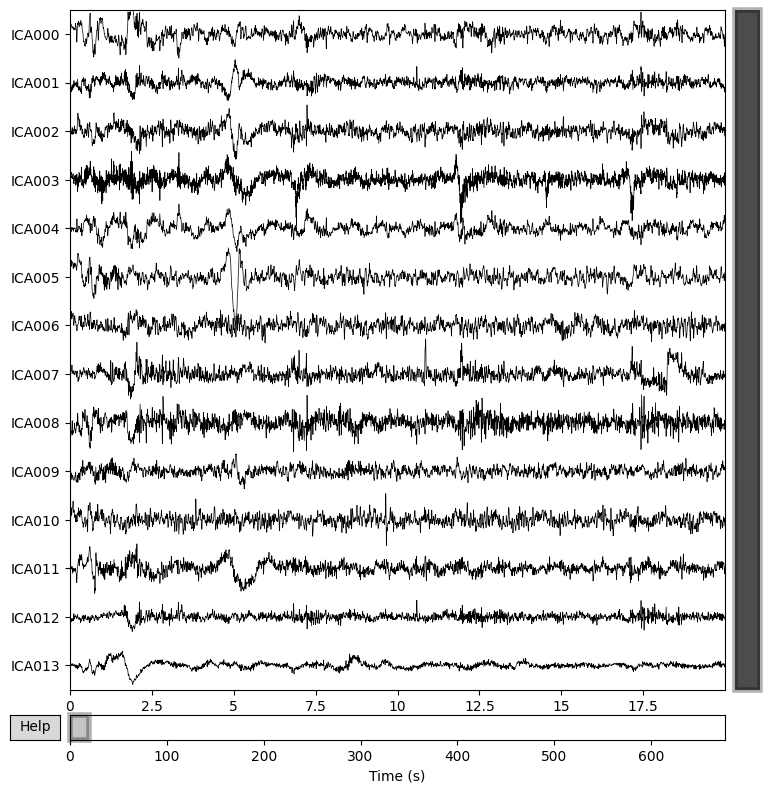

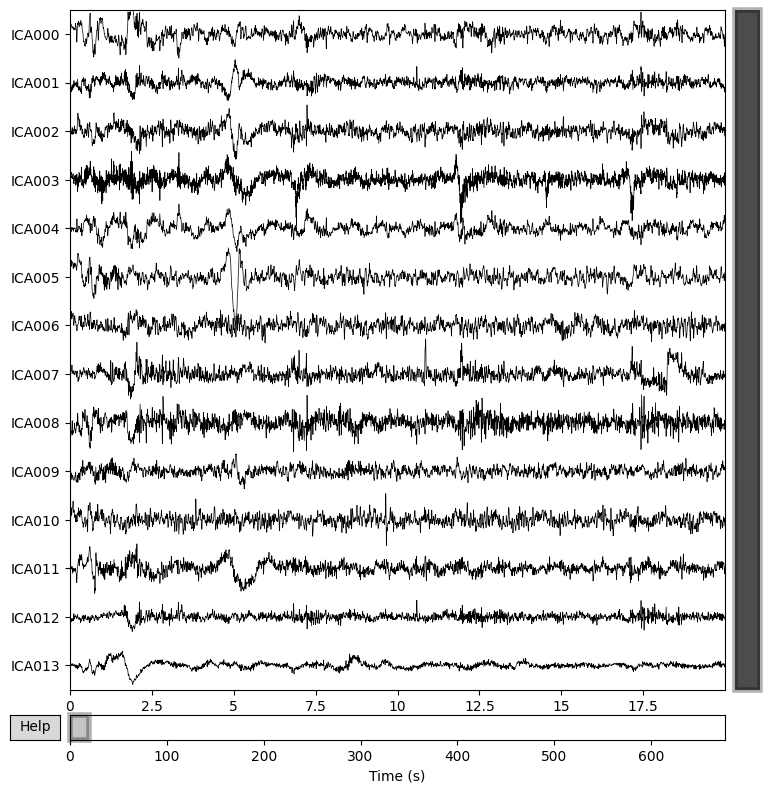

In [20]:
ica2 = mne.preprocessing.ICA(n_components=14, method='picard', random_state=15)
ica2.fit(raw)
ica2.plot_sources(raw)

In [21]:
epochs_cleaned = mne.Epochs(raw, events, reject=reject, event_id=event_id, picks='eeg', event_repeated='drop')

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
589 matching events found
Setting baseline interval to [-0.19910931587219238, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['T7']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['T8']
    Rejecting  epoch based on EEG : ['FC5']
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


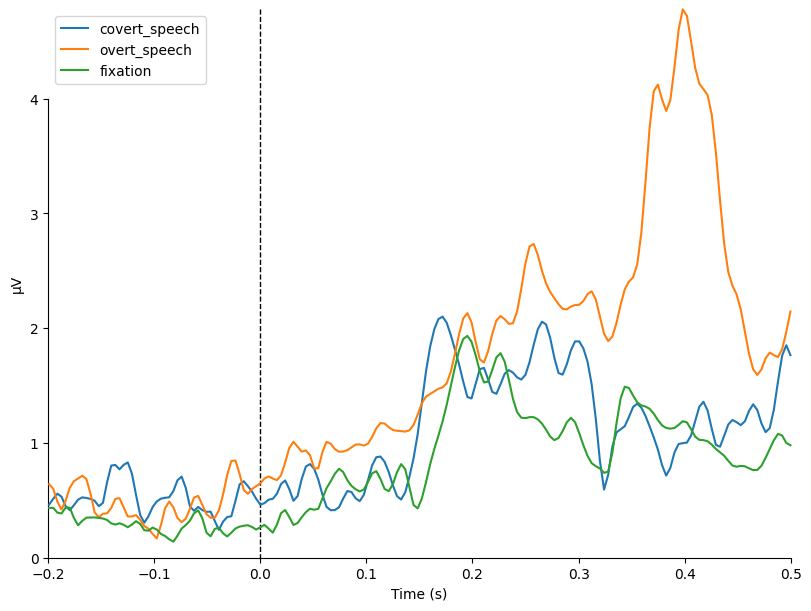

[<Figure size 800x600 with 1 Axes>]

In [22]:
mne.viz.plot_compare_evokeds([epochs_cleaned['covert_speech'].average(), epochs_cleaned['overt_speech'].average(), epochs_cleaned['fixation'].average()])

Effective window size : 7.996 (s)
Plotting power spectral density (dB=True).


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


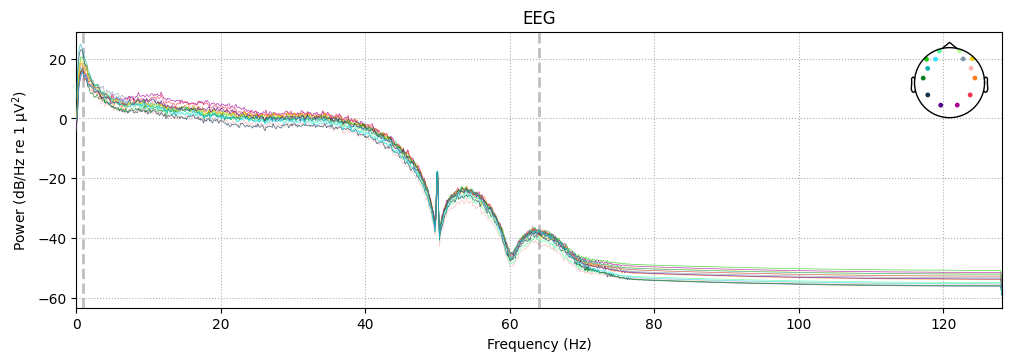

In [25]:
raw.compute_psd().plot()

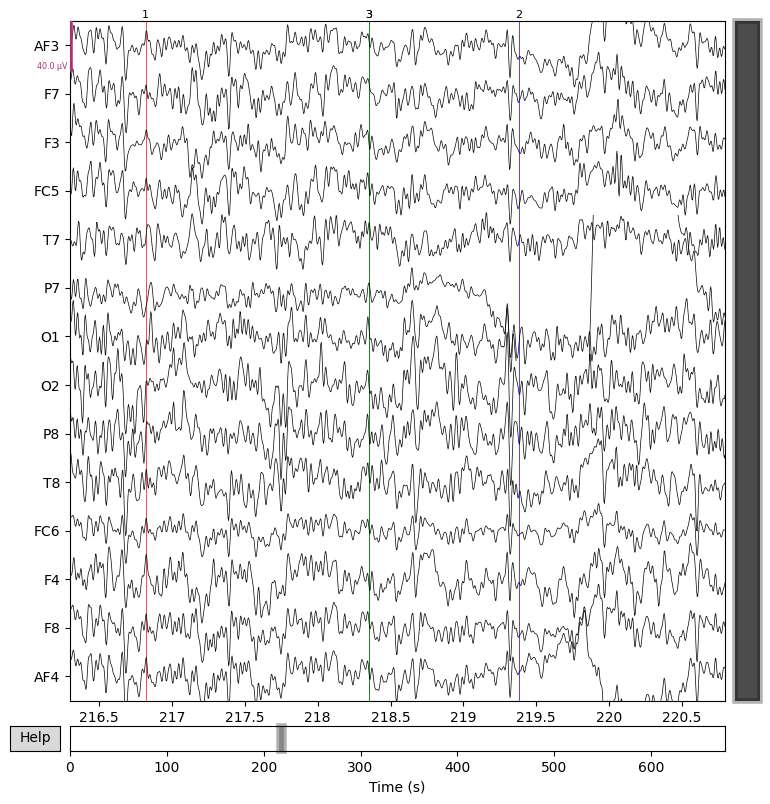

In [49]:
event_dict = {
    1: 'covert_speech',
    2: 'overt_speech',
    3: 'fixation',
}
event_color = {
    1: 'red', # covert
    2: 'blue', # overt
    3: 'green', #fixation
}
raw.plot(events=events, duration=4.5, start=216.3, event_color=event_color, show=False)

In [32]:
events

array([[    31,      0,      3],
       [    31,      0,      3],
       [   294,      0,      2],
       ...,
       [172340,      0,      1],
       [172730,      0,      3],
       [172730,      0,      3]])

In [33]:
print(np.unique(events[:, 2]))

[1 2 3]


In [63]:
df["FE.UpperFaceAction"].value_counts()

FE.UpperFaceAction
64.0    15450
1.0      6164
32.0       40
Name: count, dtype: int64

In [64]:
df[df["FE.UpperFaceAction"]==64.0]

,Timestamp,OriginalTimestamp,EEG.Counter,EEG.Interpolated,EEG.AF3,EEG.F7,EEG.F3,EEG.FC5,EEG.T7,EEG.P7,...,POW.AF4.Gamma,MC.Action,MC.ActionPower,MC.IsActive,FE.BlinkWink,FE.HorizontalEyesDirection,FE.UpperFaceAction,FE.UpperFaceActionPower,FE.LowerFaceAction,FE.LowerFaceActionPower
1,1.748951e+09,1.748951e+09,18.0,0.0,4259.743652,4330.384766,4268.974121,4288.205078,4301.025879,4335.384766,...,0.313603,1.0,0.0,0.0,0.0,0.0,64.0,0.056977,1.0,0.0
9,1.748951e+09,1.748951e+09,26.0,0.0,4247.692383,4328.333496,4277.948730,4291.794922,4325.384766,4356.025879,...,NaN,NaN,NaN,NaN,0.0,0.0,64.0,0.056977,1.0,0.0
17,1.748951e+09,1.748951e+09,34.0,0.0,4239.230957,4319.615234,4274.102539,4283.205078,4303.205078,4347.692383,...,NaN,NaN,NaN,NaN,0.0,0.0,64.0,0.056977,1.0,0.0
25,1.748951e+09,1.748951e+09,42.0,0.0,4241.922852,4318.077148,4270.512695,4287.820313,4318.974121,4357.563965,...,NaN,NaN,NaN,NaN,0.0,0.0,64.0,0.056977,1.0,0.0
129,1.748951e+09,1.748951e+09,146.0,0.0,4276.282227,4301.666504,4261.538574,4280.512695,4306.410156,4343.846191,...,0.346257,1.0,0.0,0.0,0.0,0.0,64.0,0.100717,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173193,1.748952e+09,1.748952e+09,154.0,0.0,4268.589844,4323.717773,4262.179688,4269.230957,4305.384766,4353.077148,...,NaN,NaN,NaN,NaN,0.0,0.0,64.0,0.146865,1.0,0.0
173201,1.748952e+09,1.748952e+09,162.0,0.0,4260.512695,4327.179688,4268.333496,4277.692383,4312.948730,4355.769043,...,NaN,NaN,NaN,NaN,0.0,0.0,64.0,0.146865,1.0,0.0
173209,1.748952e+09,1.748952e+09,170.0,0.0,4288.333496,4348.461426,4279.102539,4287.051270,4328.333496,4366.153809,...,NaN,NaN,NaN,NaN,0.0,0.0,64.0,0.146865,1.0,0.0
173217,1.748952e+09,1.748952e+09,178.0,0.0,4280.384766,4346.922852,4276.410156,4286.666504,4318.077148,4358.077148,...,0.802335,1.0,0.0,0.0,0.0,0.0,64.0,0.182313,1.0,0.0


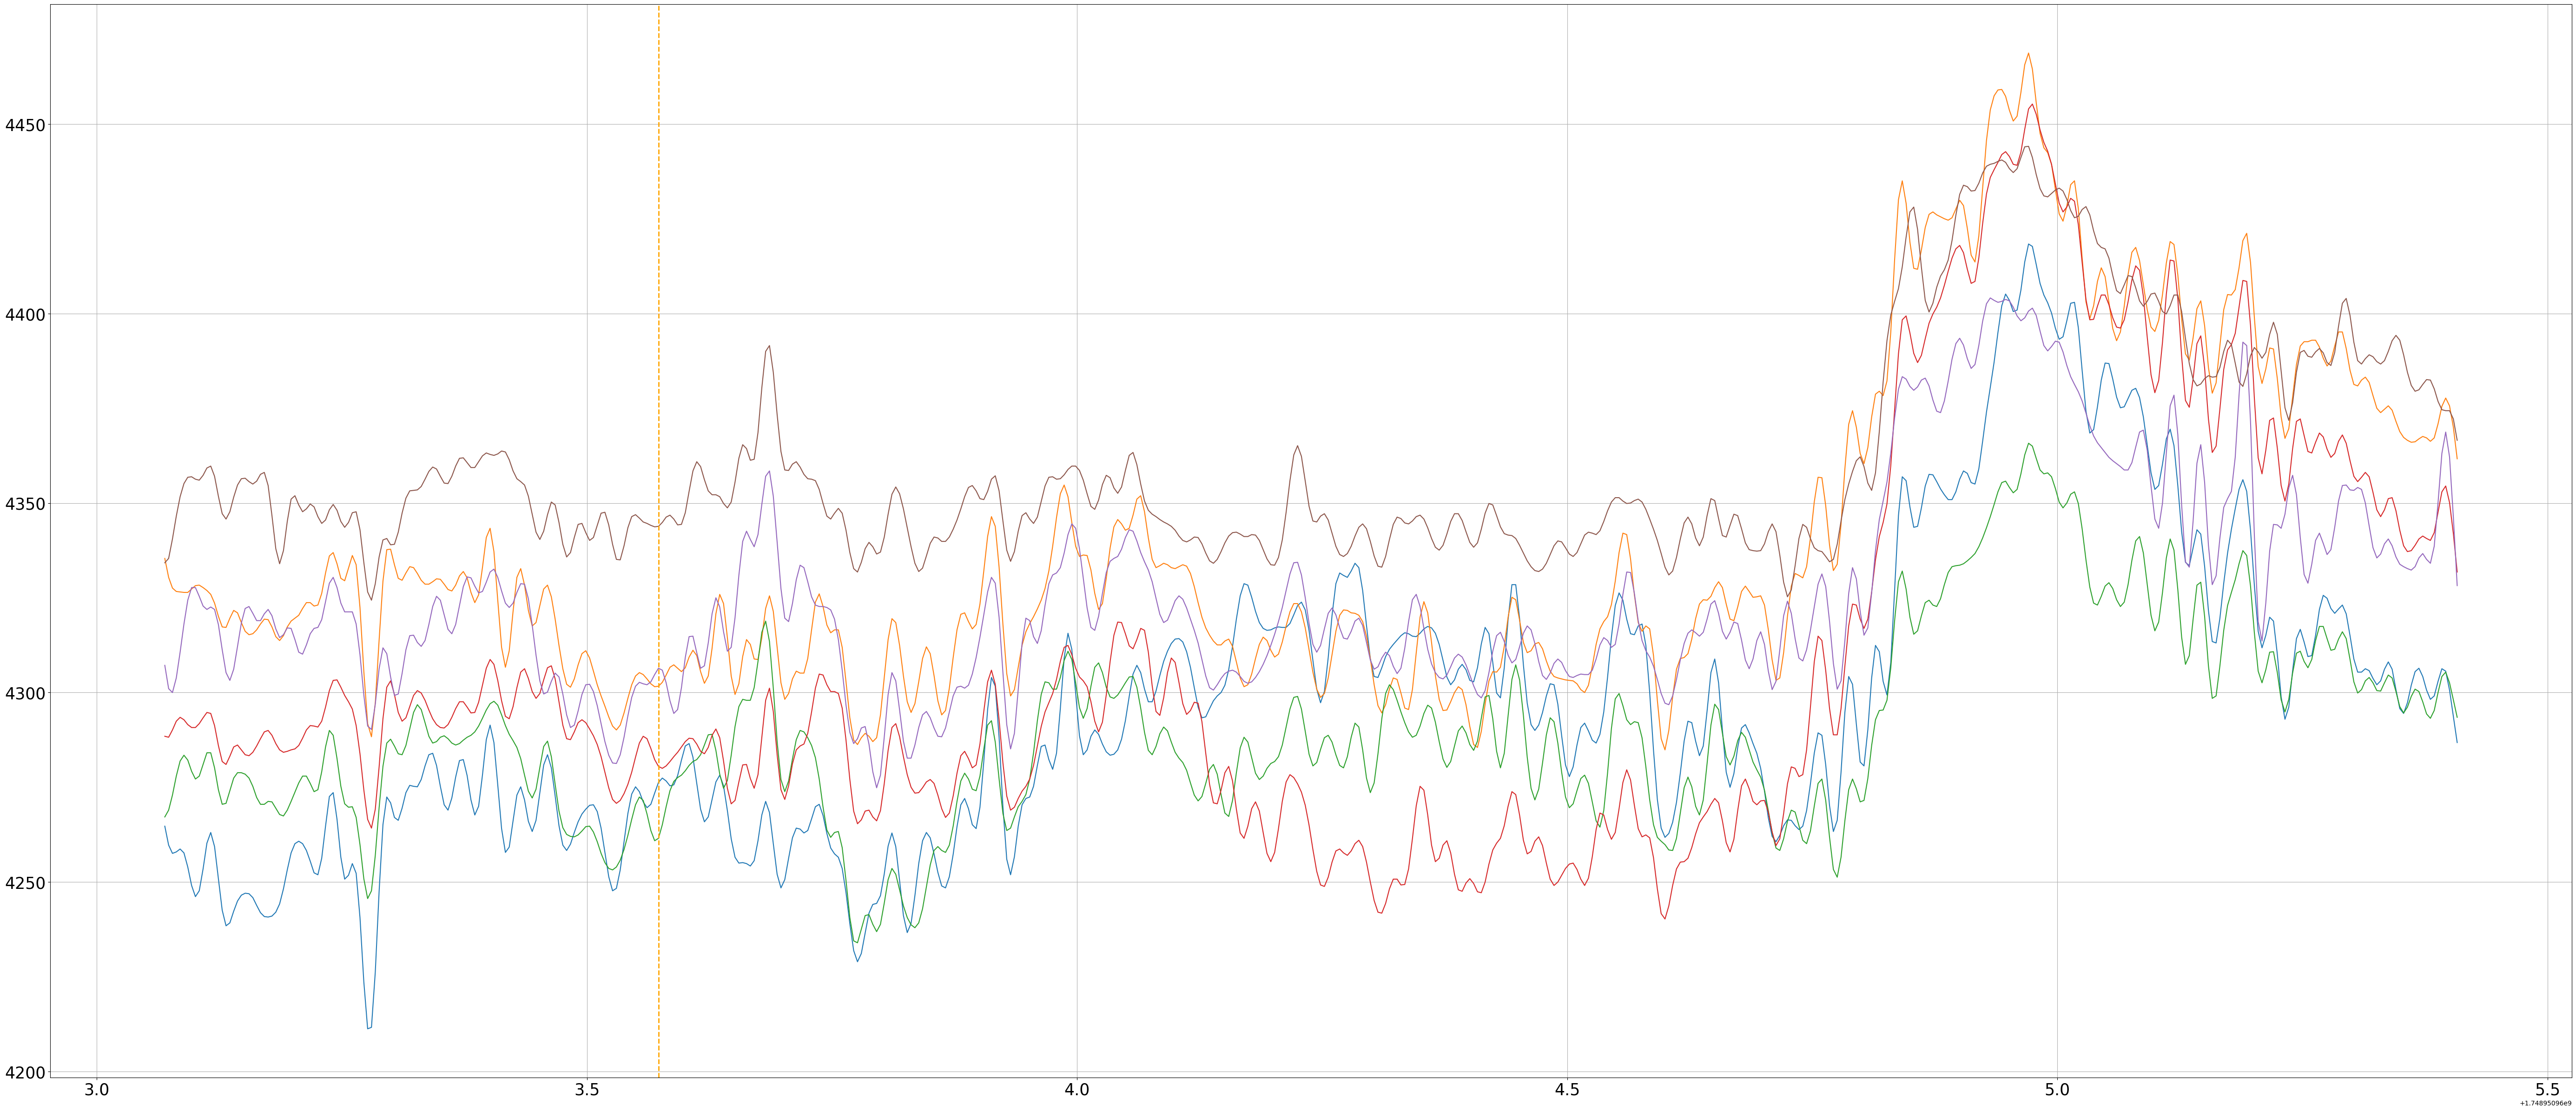

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(70, 30))
for col in ['EEG.AF3', "EEG.F7", "EEG.F3", "EEG.FC5", "EEG.T7", "EEG.P7"]:
    plt.plot(df[[col,'Timestamp']][0:600].fillna(0)["Timestamp"], df[col][0:600].fillna(0))
    # plt.title(col)
    # for event in logs["1748954273361"]:
    #     if event[0] < df['Timestamp'].iloc[60000] and event[0] > df['Timestamp'].iloc[40000]:
    # #         plt.axvline(x=event[0], color=event[1], linestyle='--', linewidth=2)
    # for entry in df[df['PM.Engagement.Max'].isnull()==False]["Timestamp"]:
    #     if entry < df['Timestamp'].iloc[60000] and entry > df['Timestamp'].iloc[40000]:
    #         plt.axvline(x=entry, color='green', linestyle='-', linewidth=2)
    # for entry in df[df["FE.BlinkWink"].isnull() == False]["Timestamp"]:
    #     if entry < df['Timestamp'].iloc[50000] and entry > df['Timestamp'].iloc[40000]:
    #         plt.axvline(x=entry, color='orange', linestyle=':', linewidth=2)
plt.grid(True)

plt.axvline(x=df['Timestamp'].iloc[129], color='orange', linestyle='--', linewidth=2)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
    # plt.title(f"{col}", fontsize=30)
plt.show()

In [62]:
df.columns.tolist()

['Timestamp',
 'OriginalTimestamp',
 'EEG.Counter',
 'EEG.Interpolated',
 'EEG.AF3',
 'EEG.F7',
 'EEG.F3',
 'EEG.FC5',
 'EEG.T7',
 'EEG.P7',
 'EEG.O1',
 'EEG.O2',
 'EEG.P8',
 'EEG.T8',
 'EEG.FC6',
 'EEG.F4',
 'EEG.F8',
 'EEG.AF4',
 'EEG.RawCq',
 'EEG.Battery',
 'EEG.BatteryPercent',
 'MarkerIndex',
 'MarkerType',
 'MarkerValueInt',
 'EEG.MarkerHardware',
 'CQ.AF3',
 'CQ.F7',
 'CQ.F3',
 'CQ.FC5',
 'CQ.T7',
 'CQ.P7',
 'CQ.O1',
 'CQ.O2',
 'CQ.P8',
 'CQ.T8',
 'CQ.FC6',
 'CQ.F4',
 'CQ.F8',
 'CQ.AF4',
 'CQ.Overall',
 'EQ.SampleRateQuality',
 'EQ.OVERALL',
 'EQ.AF3',
 'EQ.F7',
 'EQ.F3',
 'EQ.FC5',
 'EQ.T7',
 'EQ.P7',
 'EQ.O1',
 'EQ.O2',
 'EQ.P8',
 'EQ.T8',
 'EQ.FC6',
 'EQ.F4',
 'EQ.F8',
 'EQ.AF4',
 'MOT.CounterMems',
 'MOT.InterpolatedMems',
 'MOT.Q0',
 'MOT.Q1',
 'MOT.Q2',
 'MOT.Q3',
 'MOT.AccX',
 'MOT.AccY',
 'MOT.AccZ',
 'MOT.MagX',
 'MOT.MagY',
 'MOT.MagZ',
 'PM.Attention.IsActive',
 'PM.Attention.Scaled',
 'PM.Attention.Raw',
 'PM.Attention.Min',
 'PM.Attention.Max',
 'PM.Engagement.IsAc